### Librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import seaborn as sns

## Circuito RC

### Funciones

In [41]:
# =========================
# FUNCION PARA Ts y Yf
# =========================
def calcular_metricas(t, y):
    Yf = y[-1]

    # MÉTRICAS 1er ORDEN
    y_95 = 0.95 * Yf
    y_10 = 0.10 * Yf
    
    idx_95 = np.where(y >= y_95)[0]
    idx_95 = idx_95[0] if len(idx_95) > 0 else None
    T95 = t[idx_95] if idx_95 is not None else None

    idx_10 = np.where(y >= y_10)[0]
    idx_10 = idx_10[0] if len(idx_10) > 0 else None
    T10 = t[idx_10] if idx_10 is not None else None

    # MÉTRICAS 2do ORDEN
    y_max = np.max(y)
    Mp = ((y_max - Yf) / Yf) * 100 if Yf != 0 else 0

    # Tiempo de establecimiento (2%)
    banda = 0.02 * Yf
    Ts = None

    for i in range(len(y)):
        if np.all(np.abs(y[i:] - Yf) <= banda):
            Ts = t[i]
            break

    return Yf, T95, idx_95, T10, idx_10, Mp, Ts


# =========================
# FUNCION PARA GRAFICAR
# =========================
def graficar_respuesta(t_out, y, Yf, T95, idx_95, i, label, color):
    
    plt.plot(t_out, y, label=label, color=color)
    plt.plot(t_out[idx_95], y[idx_95], 'o', color=color, markersize=5)

    offset_y = 0.04 * Yf
    offset_x = 0.3
    direction = 1 if i % 2 == 0 else -1

    plt.text(
        t_out[idx_95] + offset_x,
        y[idx_95] - direction * offset_y,
        f'T_{95}={T95:.2f}s',
        fontsize=11,
        fontfamily='serif',
        fontweight='bold'
    )

def capacitor_comercial(C):
    serie = np.array([1.0, 1.2, 1.5, 1.8, 2.2, 2.7, 3.3, 3.9,
                      4.7, 5.6, 6.8, 8.2])
    
    exp = int(np.floor(np.log10(C)))
    base = C / (10**exp)
    
    idx = np.argmin(np.abs(serie - base))
    C_com = serie[idx] * (10**exp)
    
    return C_com

###  PARTE 1: LAZO ABIERTO

#### LEER: si quieres podemos cambiar la forma d e la grafica 


===== LAZO ABIERTO =====

Calculando para τ = 0.47 s...
C1 = 47.0 µF
R = 10000 Ω
Yf = 1.000
T10 ≈ 0.080 s
T95 ≈ 1.441 s

Calculando para τ = 4.70 s...
C1 = 47.0 µF
R = 100000 Ω
Yf = 1.000
T10 ≈ 0.521 s
T95 ≈ 14.094 s

Calculando para τ = 8.46 s...
C1 = 47.0 µF
R = 180000 Ω
Yf = 0.991
T10 ≈ 0.921 s
T95 ≈ 24.064 s


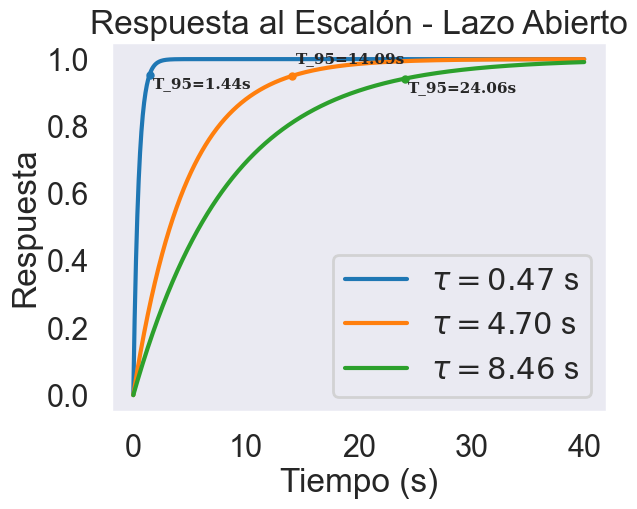

In [42]:
C1 = 47 * 1e-6 #|µF
R1 = 10000 # 10kΩ
tao1 = R1 * C1  # 0.47 s 1 Rango

R2 = 100000 # 100kΩ
tao2 = R2 * C1  # 4.7 s  2 Rango

R3 = 180000 # 180kΩ
tao3 = R3 * C1  # 9.4 s 3 Rango

taos = [tao1, tao2, tao3]
t = np.linspace(0, 40, 1000)


print("\n===== LAZO ABIERTO =====")
plt.figure()
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
sns.set_theme(
    context='poster',
    style='darkgrid',
)

for i, tao in enumerate(taos):

    print(f"\nCalculando para τ = {tao:.2f} s...")
    
    color = colores[i % len(colores)] 
    sistema = ctrl.TransferFunction([1], [tao, 1])
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, T95, idx_95, T10, idx_10, _, _ = calcular_metricas(t_out, y)

    print(f"C1 = {C1 * 1e6:.1f} µF")
    print(f"R = {tao / C1:.0f} Ω")
    print(f"Yf = {Yf:.3f}")
    print(f"T10 ≈ {T10:.3f} s")
    print(f"T95 ≈ {T95:.3f} s")



    graficar_respuesta(t_out, y, Yf, T95, idx_95, i,
                        label=f'$\\tau = {tao:.2f}$ s', color=color)

plt.grid()
plt.xlabel('Tiempo (s)')
plt.ylabel('Respuesta')
plt.title('Respuesta al Escalón - Lazo Abierto')
plt.legend()


In [44]:
print("\n===== RESULTADOS =====")
print(f"{'τ (s)':<8}{'Yf':<8}{'T10 (s)':<10}{'y(T10)':<10}{'T95 (s)':<10}{'y(T95)':<10}{'Ts (s)':<10}")

for tao in taos:
    sistema = ctrl.TransferFunction([1], [tao, 1])
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, T95, idx_95, T10, idx_10, _, _ = calcular_metricas(t_out, y)
    
    Ts = T95 - T10 if (T95 is not None and T10 is not None) else None
    
    y_T10 = y[idx_10] if idx_10 is not None else None
    y_T95 = y[idx_95] if idx_95 is not None else None

    print(f"{tao:<8.2f}{Yf:<8.2f}{T10:<10.2f}{y_T10:<10.2f}{T95:<10.2f}{y_T95:<10.2f}{Ts:<10.2f}")


===== RESULTADOS =====
τ (s)   Yf      T10 (s)   y(T10)    T95 (s)   y(T95)    Ts (s)    
0.47    1.00    0.08      0.16      1.44      0.95      1.36      
4.70    1.00    0.52      0.10      14.09     0.95      13.57     
8.46    0.99    0.92      0.10      24.06     0.94      23.14     


###  PARTE 2: LAZO CERRADO


===== LAZO CERRADO =====

K = 0.5
Yf = 0.333
T10 ≈ 0.240 s
T95 ≈ 6.006 s

K = 2
Yf = 0.667
T10 ≈ 0.120 s
T95 ≈ 3.003 s

K = 5
Yf = 0.833
T10 ≈ 0.080 s
T95 ≈ 1.522 s

K = 10
Yf = 0.909
T10 ≈ 0.040 s
T95 ≈ 0.841 s


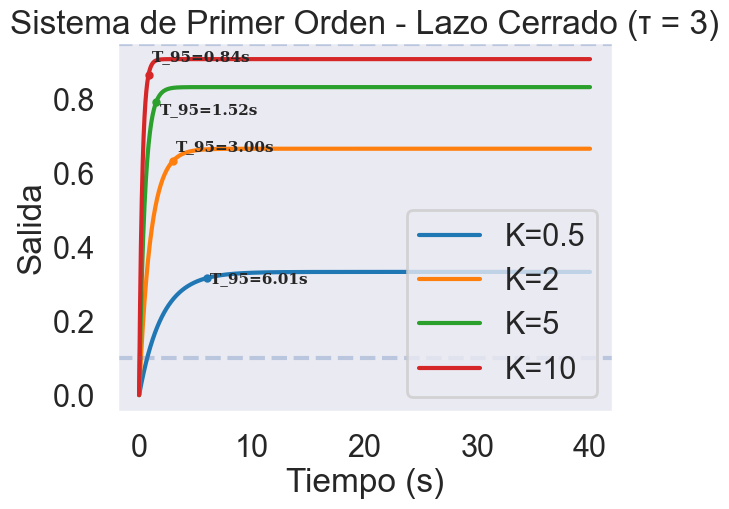

In [45]:
K_values = [0.5, 2, 5, 10]
tau = 3

t = np.linspace(0, 40, 1000)

colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure()
print("\n===== LAZO CERRADO =====")

for i, K in enumerate(K_values):
    
    color = colores[i % len(colores)]

    G = ctrl.TransferFunction([1], [tau, 1])
    sistema_cerrado = ctrl.feedback(K * G, 1)
    
    t_out, y = ctrl.step_response(sistema_cerrado, t)
    
    Yf, T95, idx_95, T10, idx_10, _, _ = calcular_metricas(t_out, y)
    
    print(f"\nK = {K}")
    print(f"Yf = {Yf:.3f}")
    print(f"T10 ≈ {T10:.3f} s")
    print(f"T95 ≈ {T95:.3f} s")

    graficar_respuesta(
        t_out, y, Yf, T95, idx_95,
        i,
        label=f'K={K}',
        color=color
    )

# Líneas de referencia (mejor una sola vez)
plt.axhline(0.10, linestyle='--', alpha=0.3)
plt.axhline(0.95, linestyle='--', alpha=0.3)

plt.title("Sistema de Primer Orden - Lazo Cerrado (τ = 3)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.legend()
plt.grid()
plt.show()

## Sistema RLC


===== CASO 1: ζ = 0.02 FIJO =====

ωn deseado = 176000
C teórico = 6.87e-08 F
C comercial = 6.80e-08 F
R ajustado = 3.33 Ω
ζ real ≈ 0.02
Yf=1.346, Mp=44.06%, Ts=1.995996e-04s
tao= 0.00
Frecuencia recomendada= 220.00 Hz

ωn deseado = 200000
C teórico = 5.32e-08 F
C comercial = 5.60e-08 F
R ajustado = 3.66 Ω
ζ real ≈ 0.02
Yf=0.858, Mp=125.85%, Ts=1.997998e-04s
tao= 0.00
Frecuencia recomendada= 250.00 Hz


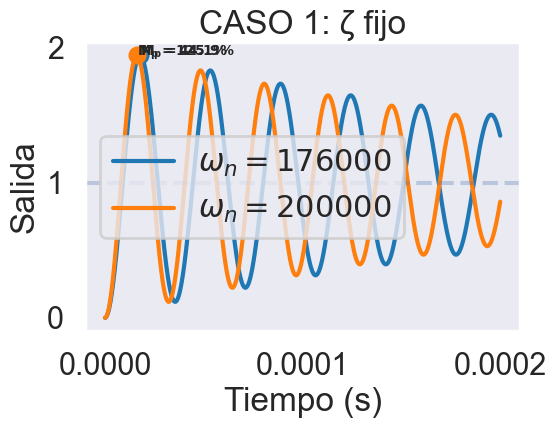

In [50]:
print("\n===== CASO 1: ζ = 0.02 FIJO =====")

zeta = 0.02
L = 470e-6

wn_values = [176000, 200000]

colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure()

for i, wn in enumerate(wn_values):

    color = colores[i % len(colores)]

    # 1. C teórico
    C_teo = 1 / (L * wn**2)
    
    # 2. C comercial
    C = capacitor_comercial(C_teo)
    
    # 3. R ajustado
    R = 2 * zeta * np.sqrt(L / C)
    
    # Sistema
    num = [1]
    den = [L*C, R*C, 1]
    
    tao = 1 / (wn * zeta)
    frecuencia_entrada = 1 / (tao * 16)
    
    sistema = ctrl.TransferFunction(num, den)
    
    t = np.linspace(0, 0.0002, 1000)
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, _, _, _, _, Mp, Ts = calcular_metricas(t_out, y)
    
    print(f"\nωn deseado = {wn}")
    print(f"C teórico = {C_teo:.2e} F")
    print(f"C comercial = {C:.2e} F")
    print(f"R ajustado = {R:.2f} Ω")
    print(f"ζ real ≈ {zeta}")
    print(f"Yf={Yf:.3f}, Mp={Mp:.2f}%, Ts={Ts:.6e}s")
    print(f'tao= {tao:.2f}')
    print(f'Frecuencia recomendada= {frecuencia_entrada:.2f} Hz')
    
    # 🔹 Curva principal
    plt.plot(
        t_out, y,
        label=f'$\\omega_n={wn}$',
        color=color
    )

    # 🔹 Punto de sobreimpulso (si existe)
    if Mp is not None:
        idx_mp = np.argmax(y)
        plt.plot(t_out[idx_mp], y[idx_mp], 'o', color=color)

        plt.text(
            t_out[idx_mp],
            y[idx_mp],
            f'$\\mathbf{{M_p={Mp:.1f}\\%}}$',
            fontsize=10
        )

# 🔹 Líneas referencia (opcional)
plt.axhline(1, linestyle='--', alpha=0.3)

plt.title("CASO 1: ζ fijo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


===== CASO 2: ωn FIJO (C comercial) =====

C teórico = 68.69 nF
C comercial = 68.00 nF

ζ = 0.02
R = 3.33 Ω
ωn = 176000
Yf = 1.000
Mp = 93.17%
Ts = 8.356451e-04 s
tao= 0.00
Frecuencia recomendada= 220.0 Hz

ζ = 1.2
R = 199.53 Ω
ωn = 176000
Yf = 1.000
Mp = 0.00%
Ts = 3.505541e-05 s
tao= 0.00
Frecuencia recomendada= 13200.0 Hz


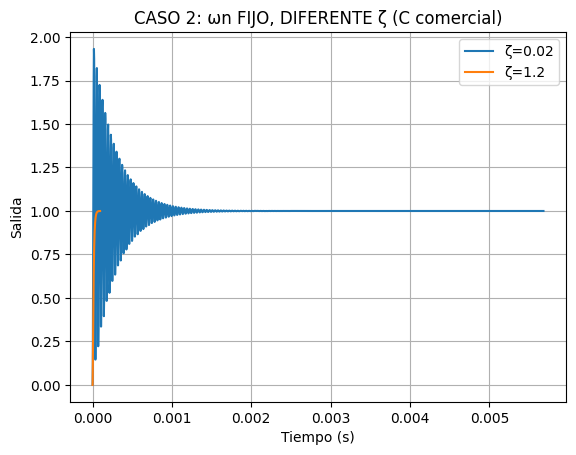

In [34]:
# =========================
# CASO 2: ωn FIJO, DIFERENTE ζ (C comercial)
# =========================
print("\n===== CASO 2: ωn FIJO (C comercial) =====")

wn = 176000

# 1. C teórico
C_teo = 1 / (L * wn**2)

# 2. C comercial
C = capacitor_comercial(C_teo)

print(f"\nC teórico = {C_teo*1e9:.2f} nF")
print(f"C comercial = {C*1e9:.2f} nF")

zeta_values = [0.02, 1.2]

plt.figure()

for zeta in zeta_values:
    
    # 3. Recalcular R con C real
    R = 2 * zeta * np.sqrt(L/C)
    
    num = [1]
    den = [L*C, R*C, 1]
    
    sistema = ctrl.TransferFunction(num, den)
    
    # 🔥 tiempo correcto
    Ts_aprox = 4 / (zeta * wn)
    t = np.linspace(0, 5*Ts_aprox, 2000)
    
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, Mp, Ts = calcular_metricas(t_out, y)
    tao= 1/(wn*zeta)
    frecuancia_entrada=1/(tao*16)
    
    print(f"\nζ = {zeta}")
    print(f"R = {R:.2f} Ω")
    print(f"ωn = {wn}")
    print(f"Yf = {Yf:.3f}")
    print(f"Mp = {Mp:.2f}%")
    print(f"Ts = {Ts:.6e} s")
    print(f'tao= {tao:.2f}')
    print(f'Frecuencia recomendada= {frecuancia_entrada} Hz')
    
    plt.plot(t_out, y, label=f"ζ={zeta}")

plt.title("CASO 2: ωn FIJO, DIFERENTE ζ (C comercial)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.legend()
plt.grid()